In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.utils.dataframe_utils import create_dataframe

df_train_seg = create_dataframe(
    "../data/train.csv", 
    "../data/boneage-training-segmented-gray", 
    segmented=True)

df_test = create_dataframe(
    "../data/test.csv",
    "../data/boneage-test-dataset", 
    segmented=False)

df_test_seg = create_dataframe(
    "../data/test.csv",
    "../data/boneage-test-segmented-gray", 
    segmented=True)

In [ ]:
import json

with open("src/config/stats.json") as f:
    stats = json.load(f)

m = stats["mean"]
s = stats["std"]


In [4]:
from src.preprocessing.scaling import scaling_data_torch

df_train_seg, df_test, df_test_seg, scaler_seg = scaling_data_torch(df_train_seg, df_test, df_test_seg)

In [ ]:
from src.preprocessing.datasets import BoneAgeDataset
from src.preprocessing.transforms import transform

test_dataset = BoneAgeDataset(df_test, transform=transform)
test_seg_dataset = BoneAgeDataset(df_test_seg, transform=transform)

In [6]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

test_seg_loader = DataLoader(
    test_seg_dataset,
    batch_size=32,
    shuffle=False
)

In [7]:
from src.model.cnn_torch import BoneAgeModel

In [ ]:
import torch
device = torch.device("cuda")

model = BoneAgeModel().to(device)
model.load_state_dict(torch.load("model_results/torch_model_male.pt", map_location=device))


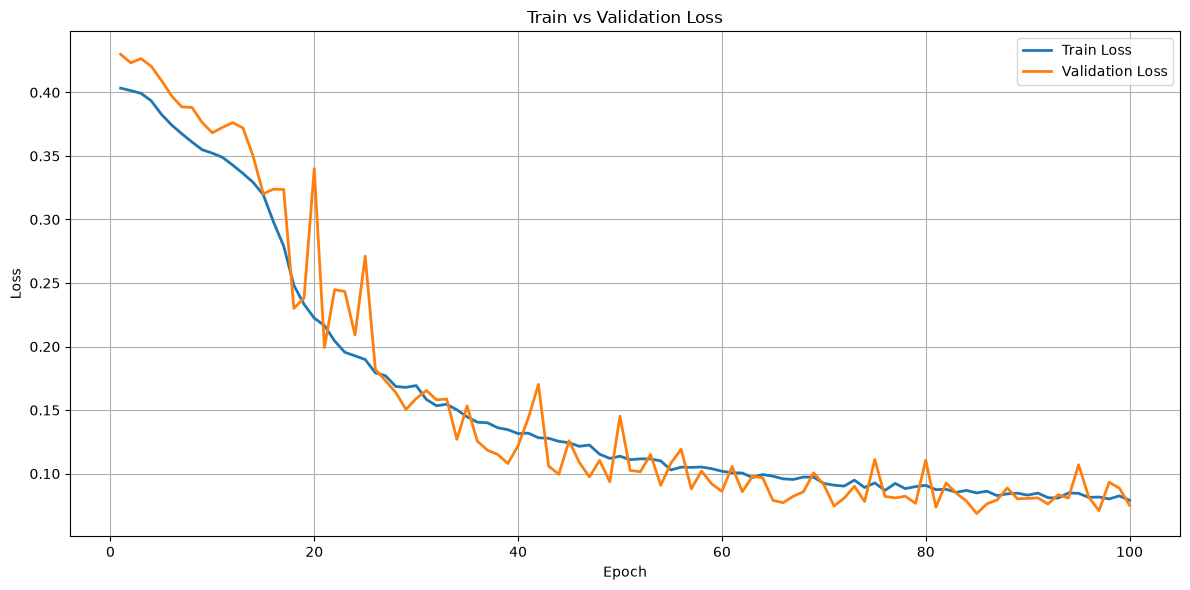

In [4]:
from src.visualization.plots import plot_loss

plot_loss("model_results/training_history_torch_male.xlsx")

In [9]:
import numpy as np
import torch

y_true = []
y_pred_seg = []
y_pred = []

model.eval()

with torch.no_grad():
    for batch in test_seg_loader:

        image = batch["image"].to(device)
        male = batch["male"].float().unsqueeze(1).to(device)
        y = batch["boneage"].to(device)

        pred_seg = model(image, male)

        y_true.append(y.cpu().numpy())
        y_pred_seg.append(pred_seg.cpu().numpy())

with torch.no_grad():
    for batch in test_loader:

        image = batch["image"].to(device)
        male = batch["male"].float().unsqueeze(1).to(device)

        pred = model(image, male)

        y_pred.append(pred.cpu().numpy())



y_true = np.concatenate(y_true)
y_pred_seg = np.concatenate(y_pred_seg)
y_pred = np.concatenate(y_pred)

In [ ]:
y_true = s * y_true + m
y_pred_seg = s * y_pred_seg + m
y_pred = s * y_pred + m

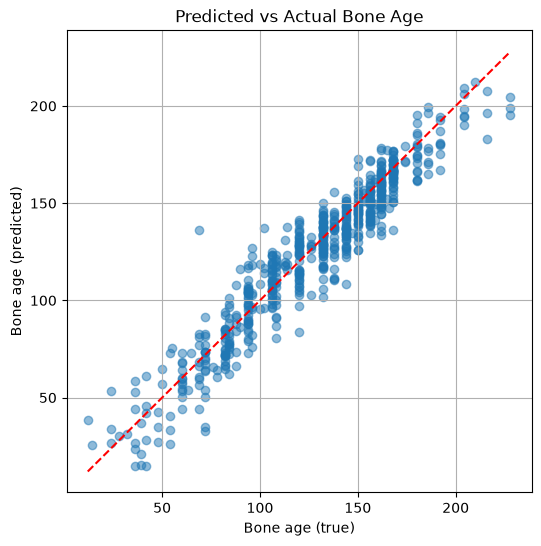

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred_seg, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Bone age (true)")
plt.ylabel("Bone age (predicted)")
plt.title("Segmented Test - Predicted vs Actual Bone Age")

plt.grid(True)
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_true, y_pred_seg)
rmse = root_mean_squared_error(y_true, y_pred_seg)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9.448654027265576
RMSE: 12.144841445438836


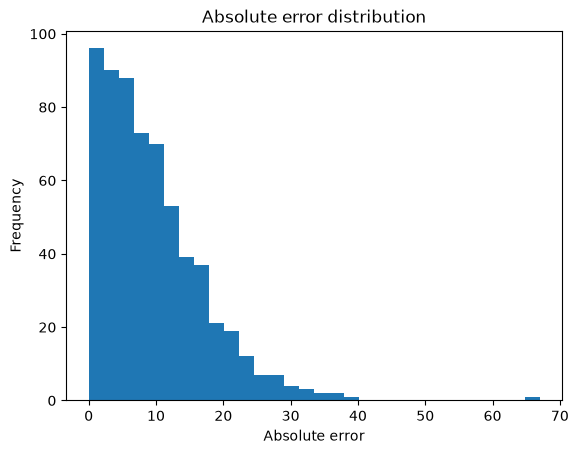

In [ ]:
import numpy as np

errors = np.abs(y_true - y_pred_seg)

plt.hist(errors, bins=30)
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Segmented Test - Absolute error distribution")
plt.show()

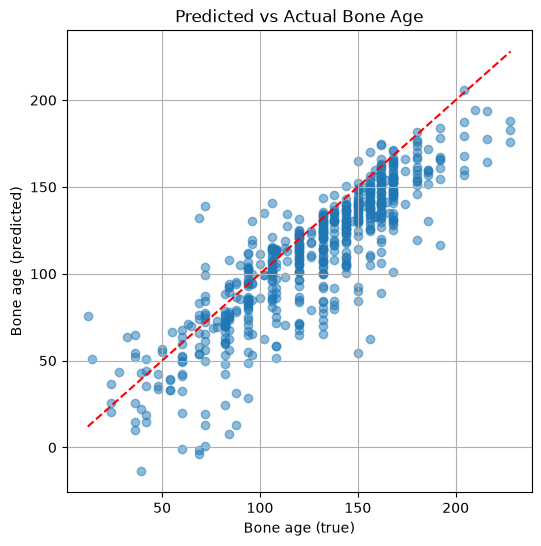

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Bone age (true)")
plt.ylabel("Bone age (predicted)")
plt.title("Original Test - Predicted vs Actual Bone Age")

plt.grid(True)
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 18.523852693734174
RMSE: 24.687922649318043


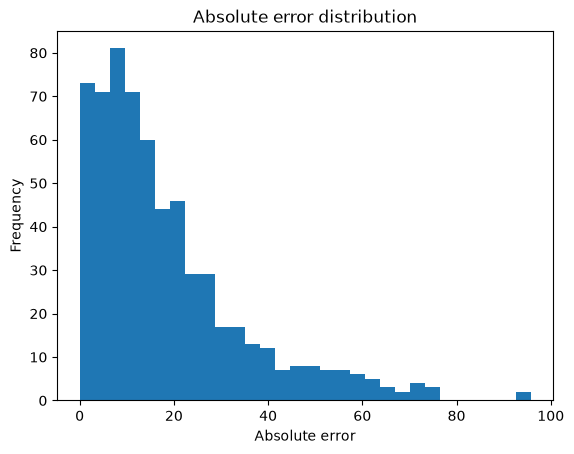

In [ ]:
import numpy as np

errors = np.abs(y_true - y_pred)

plt.hist(errors, bins=30)
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Original Test - Absolute error distribution")
plt.show()